In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
df.shape

(1000, 11)

In [4]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [7]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [8]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

## Exploratory Data Analysis (EDA)

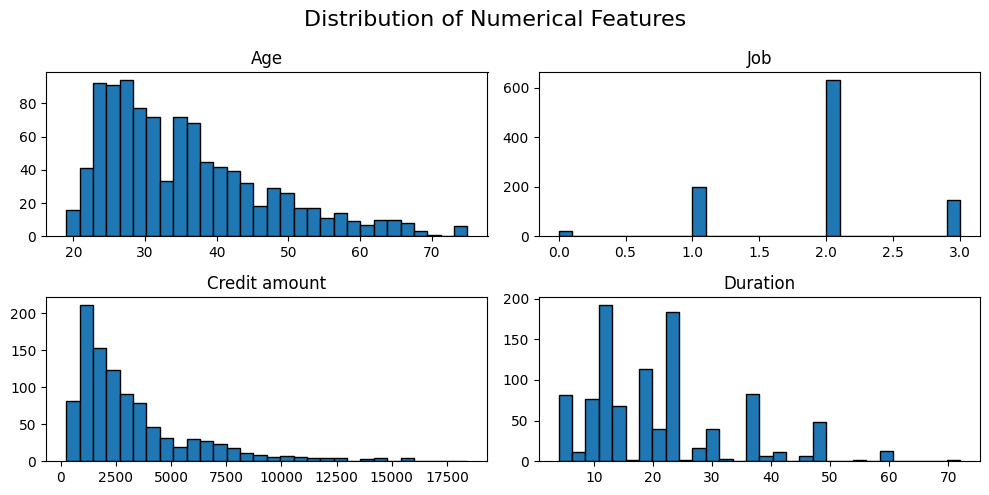

In [9]:
df[['Age', 'Job', 'Credit amount', 'Duration']].hist(bins=30, figsize=(10, 5),grid=False,edgecolor='black' )
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()  
plt.show()

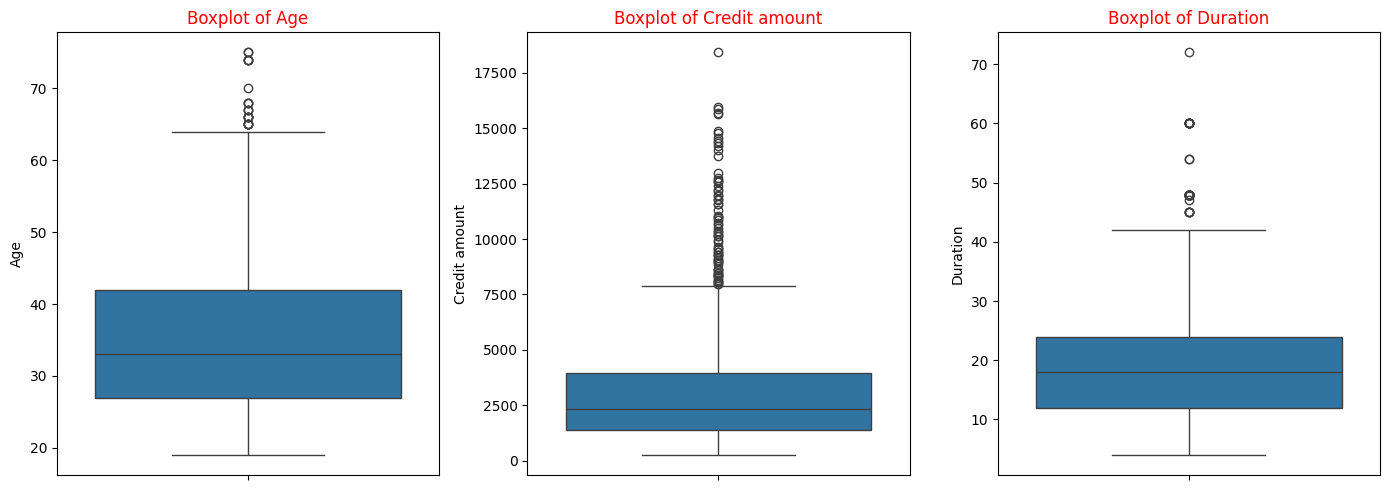

In [10]:
plt.figure(figsize=(14, 5))
for i , col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}',color='red')

plt.tight_layout()
plt.show()

In [11]:
df.query('Duration >= 60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,NaN,10144,60,radio/TV,good
255,27,male,1,own,NaN,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,NaN,NaN,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,NaN,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,NaN,15653,60,radio/TV,good
672,42,male,3,own,little,NaN,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [12]:
categorical_cols = ['Sex', 'Job' , 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

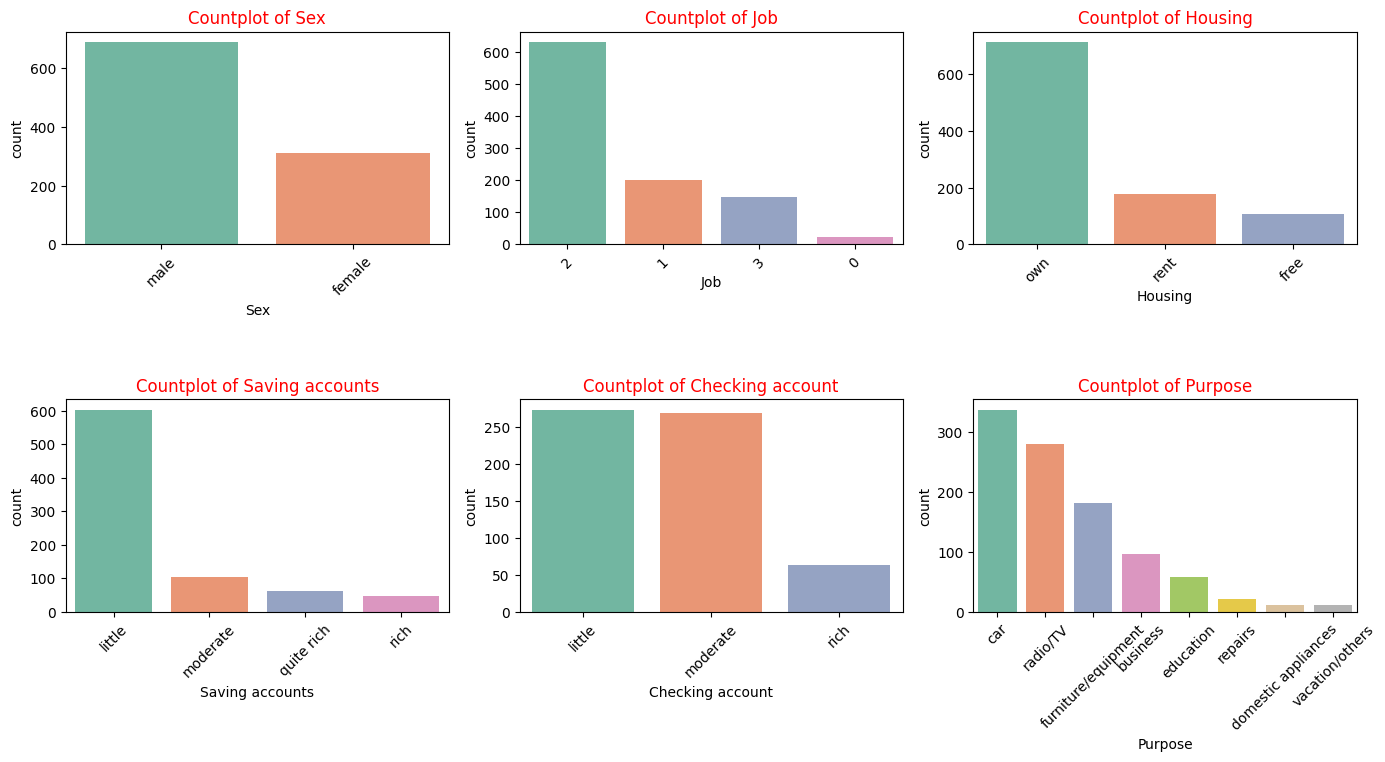

In [13]:
plt.figure(figsize=(14, 10))
for i , col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(x= col, data=df, palette='Set2', order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}',color='red')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Axes: >

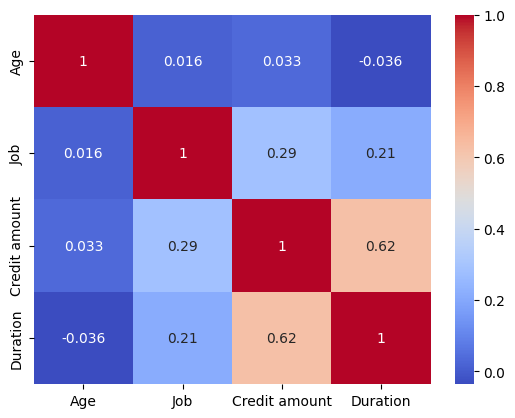

In [14]:
corr = df[['Age', 'Job', 'Credit amount', 'Duration']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [15]:
df.groupby('Job')['Credit amount'].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

In [16]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

In [17]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


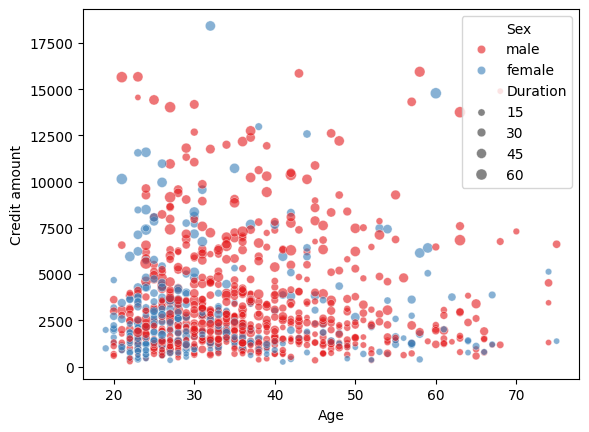

In [18]:
sns.scatterplot(data=df, x='Age', y='Credit amount', hue='Sex', size='Duration', palette='Set1', alpha=0.6)
plt.show()

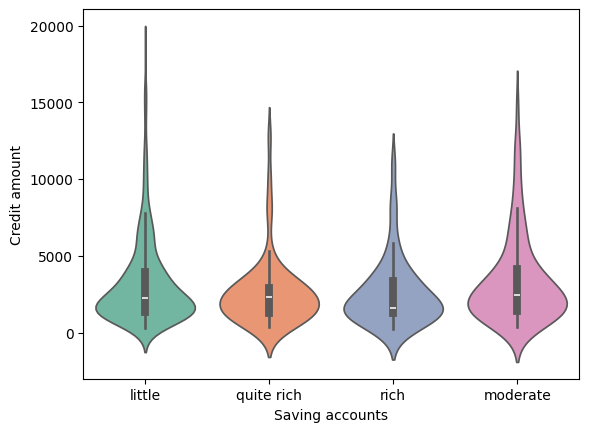

In [19]:
sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette='Set2')
plt.show()

In [20]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

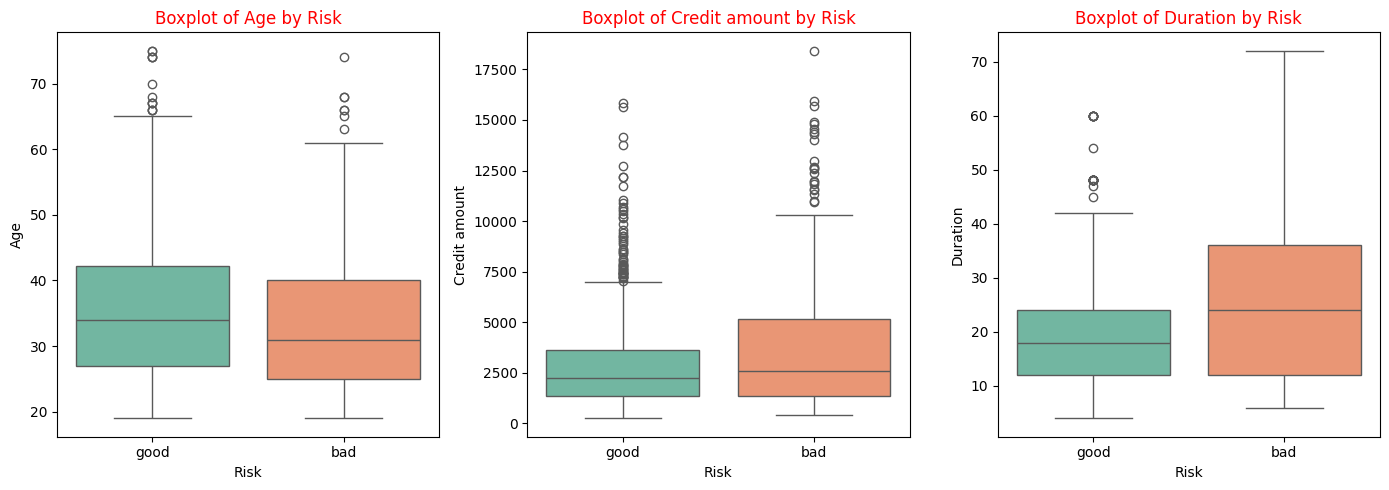

In [21]:
plt.figure(figsize=(14, 5))
for i , col in enumerate(['Age','Credit amount','Duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Risk', y=col, data=df, palette='Set2')
    plt.title(f'Boxplot of {col} by Risk',color='red')

plt.tight_layout()
plt.show()

In [22]:
df.groupby('Risk')[['Age','Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


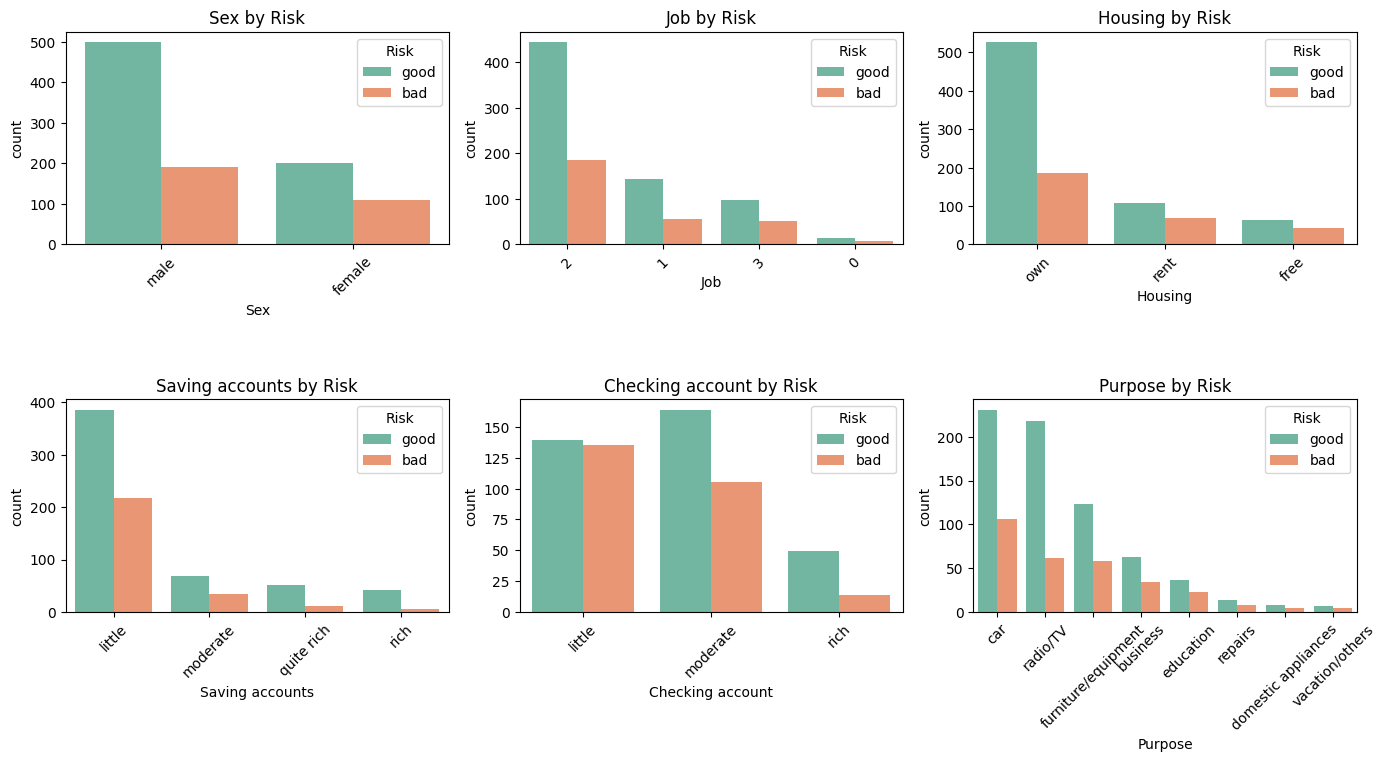

In [23]:
plt.figure(figsize=(14, 10))

for i , col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(x= col, hue='Risk', data=df, palette='Set2', order=df[col].value_counts().index)
    plt.title(f'{col} by Risk')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

## Encoding

In [25]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account','Credit amount', 'Duration']
target = ['Risk']

In [26]:
dataset = df[features + target].copy()
dataset.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,male,2,own,NaN,little,1169,6,good
1,22,female,2,own,little,moderate,5951,48,bad
2,49,male,1,own,little,NaN,2096,12,good
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad


In [27]:
dataset.shape

(1000, 9)

In [28]:
cat_cols = dataset.select_dtypes(include='object').columns.drop('Risk')
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [29]:
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    dataset[col] = le.fit_transform(dataset[col])

    le_dict[col] = le
    pickle.dump(le, open(f'{col}_encoder.pkl', 'wb'))

In [30]:
le_target = LabelEncoder()
dataset['Risk'] = le_target.fit_transform(dataset['Risk'])

In [31]:
dataset[target].value_counts()   # 1 --> good, 0 --> bad

Risk
1       700
0       300
Name: count, dtype: int64

In [32]:
pickle.dump(le_target, open('target_encoder.pkl', 'wb'))

## Dataset Split

In [33]:
X = dataset.drop('Risk', axis=1)
y = dataset['Risk']

X.shape , y.shape

((1000, 8), (1000,))

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_test.shape

((800, 8), (200, 8))

## Model Building

In [35]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    return best_model, acc, cr, grid.best_params_

In [36]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_param_grid = {
                    'max_depth': [3, 5, 7, 10, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]
                }

In [37]:
best_dt, dt_acc, dt_cr, dt_best_params = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [38]:
print("Best Decision Tree Parameters:", dt_best_params)

Best Decision Tree Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [53]:
print("Best Decision Tree Accuracy:", dt_acc)
print("\nBest Decision Tree Classification Report:\n", dt_cr)

Best Decision Tree Accuracy: 0.675

Best Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.75      0.58        60
           1       0.86      0.64      0.73       140

    accuracy                           0.68       200
   macro avg       0.67      0.70      0.66       200
weighted avg       0.74      0.68      0.69       200



In [40]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced',n_jobs=-1)
rf_param_grid = {
                    'n_estimators': [100, 200],
                    'max_depth': [5, 7, 10, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]
                }

In [41]:
best_rf, rf_acc, rf_cr, rf_best_params = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [42]:
print("Best Random Forest Parameters:", rf_best_params)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [43]:
print("Best Random Forest Accuracy:", rf_acc)
print("\nBest Random Forest Classification Report:\n", rf_cr)

Best Random Forest Accuracy: 0.75

Best Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.60      0.59        60
           1       0.83      0.81      0.82       140

    accuracy                           0.75       200
   macro avg       0.70      0.71      0.71       200
weighted avg       0.75      0.75      0.75       200



In [44]:
et = ExtraTreesClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
et_param_grid = {
                    'n_estimators': [100, 200],
                    'max_depth': [5, 7, 10, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]
                }

In [45]:
best_et, et_acc, et_cr, et_best_params = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [46]:
print("Best Extra Trees Parameters:", et_best_params)

Best Extra Trees Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [47]:
print("Best Extra Trees Accuracy:", et_acc)
print("\nBest Extra Trees Classification Report:\n", et_cr)

Best Extra Trees Accuracy: 0.715

Best Extra Trees Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.50      0.51        60
           1       0.79      0.81      0.80       140

    accuracy                           0.71       200
   macro avg       0.66      0.65      0.66       200
weighted avg       0.71      0.71      0.71       200



In [48]:
xgb = XGBClassifier(random_state=42, scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(), use_label_encoder=False, eval_metric='logloss')

xgb_param_grid = {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5, 7],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'subsample' : [0.7,1],
                    'colsample_bytree' : [0.7,1]
                }

In [49]:
best_xgb, xgb_acc, xgb_cr, xgb_best_params = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

In [50]:
print("Best XG Boost Parameters:", xgb_best_params)

Best XG Boost Parameters: {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}


In [51]:
print("Best XG Boost Accuracy:", xgb_acc)
print("\nBest XG Boost Classification Report:\n", xgb_cr)

Best XG Boost Accuracy: 0.725

Best XG Boost Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.58      0.56        60
           1       0.81      0.79      0.80       140

    accuracy                           0.72       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.73      0.72      0.73       200



## Saving Model

In [52]:
pickle.dump(best_rf, open('rf_model.pkl', 'wb'))